In [ ]:
import csv
from itertools import zip_longest
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import splrep, splev
from sklearn.decomposition import PCA
from statsmodels.nonparametric.smoothers_lowess import lowess


def calculate_plot_parameter(intensities):
    average = np.mean(intensities, axis=0)
    average = lowess_smooth(average)

    stderr = np.std(intensities, axis=0) / np.sqrt(len(intensities))
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std

def interpolate_data(values, num=1000):
    values = np.asarray(values, dtype=float)
    x = np.linspace(0, 1000, len(values))
    spl = splrep(x, values)
    new_x = np.linspace(0, 1000, num)
    new_values = splev(new_x, spl)
    return new_x, new_values


def normalize_data(list):
    list_max = max(list)
    normalized_data_1d = [ (data / list_max)for data in list]
    return normalized_data_1d

def find_baseline(values):

    values = np.array(values)   
    search_region = values[400:601]  
    min_idx_local = np.argmin(search_region)
    min_idx = min_idx_local + 400    

    half_window = 50
    start = max(0, min_idx - half_window)
    end = min(len(values), min_idx + half_window)

    window = values[start:end]

    avg_100 = np.mean(window)

    return avg_100


def calculate_plot_parameter(intensities):
    average = np.mean(intensities, axis=0)
    average = lowess_smooth(average)

    stderr = np.std(intensities, axis=0) / np.sqrt(len(intensities))
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std


def lowess_smooth (data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05 # IMPORTANT window length
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:,1]


def plot_3(intensities, average, stderr, std):

    x = np.linspace(3.7, 7, len(average))   # create x axis from 4.8 to 7

    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=0.65, linewidth=0.5)

    plt.plot(x, average, color='#313131', linewidth=3, label='Average')

    plt.fill_between(x, average - stderr, average + stderr,
                     color='gray', alpha=0.45)

    plt.fill_between(x, average - std, average + std,
                     color='gray', alpha=0.15)

    plt.xlim(3.7, 7)
    plt.xticks([4, 5, 6, 7], fontsize=12)
    plt.axvline(4, color='gray', linestyle='--', alpha=0.6)

    plt.yticks([0,1, 2, 3])
    plt.ylim(-0.5, 3)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Day")
    plt.ylabel("Recovered signal intensity")

    plt.show()


def allinone(input_folder, timestamp_file):

    file_list = sorted(input_folder.glob("*.csv"))

    half_signal = []

    dye1_signal = []

    dye2_signal = []

    for i in range(len(file_list)):
        file = file_list[i]
        df = pd.read_csv(file)
        green_data = df["green"] 
        x_interp, green_signal = interpolate_data(green_data, num=1000)

        magenta_data = df["magenta"] 
        x_interp, magenta_signal = interpolate_data(magenta_data, num=1000)

        red_data = df["red"] 
        x_interp, red_signal_ori = interpolate_data(red_data, num=1000)
        red_signal = [(i-100) for i in red_signal_ori]

        df_time = pd.read_csv(timestamp_file, header=None)

        row = df_time.iloc[i]  

        timestamp1 = row[0]
        timestamp2 = row[1]
        timestamp3 = row[2]
        timestamp4 = row[3]

        time1_extend = int(1.1 * timestamp2 - 0.1 * timestamp1)
        time2_extend = int(1.1 * timestamp3- 0.1 * timestamp4)

        left_signal = red_signal[timestamp1:time1_extend]
        right_signal = red_signal[time2_extend:timestamp4]

        _, interpolate_left = interpolate_data(left_signal, num=1000)
        _, interpolate_right = interpolate_data(right_signal, num=1000)


        baseline_left = np.mean(red_signal[timestamp2:time1_extend])
        baseline_right = np.mean(red_signal[time2_extend:timestamp3])

        relative_left = [(k/baseline_left)-1 for k in interpolate_left]
        relative_right = [(k/baseline_right)-1 for k in interpolate_right]

        interpolate_left_reverse = relative_left[::-1]
        averaged_list = [(a + b) / 2 for a, b in zip(interpolate_left_reverse, relative_right)]


        if np.max(averaged_list)>5:
            print(f'large {file}')
            print()
        else:
            half_signal.append(averaged_list)

            dye1_data = green_signal[timestamp1:timestamp4]
            _, dye1_data_data = interpolate_data(dye1_data, num=1000)
            dye1_data_data_data = normalize_data(dye1_data_data)
            dye1_signal.append(dye1_data_data_data)

            # dye2
            dye2_data = magenta_signal[timestamp1:timestamp4]
            _, dye2_data_data = interpolate_data(dye2_data, num=1000)
            dye2_data_data_data = normalize_data(dye2_data_data)
            dye2_signal.append(dye2_data_data_data)

    return dye1_signal, dye2_signal, half_signal

# Figure 4C

74


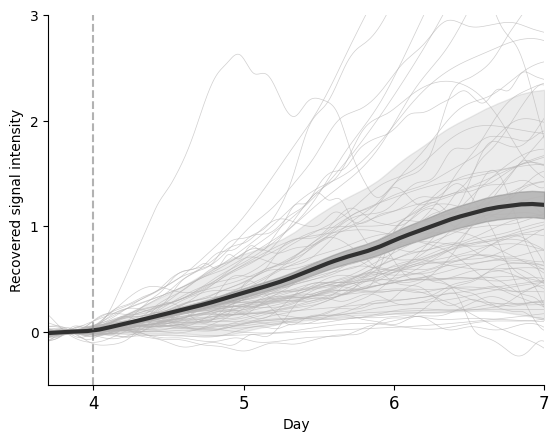

In [ ]:
input_folder = Path(r"in vitro\single traces")
timestamp_file = r"in vitro\timestamp.csv"

all_dye1, all_dye2, all_signal = allinone(input_folder, timestamp_file)

print(len(all_signal))

average_signal, stderr_signal, std_signal = calculate_plot_parameter(all_signal)
plot_3(all_signal, average_signal, stderr_signal, std_signal)

# Figure 4D

In [ ]:
# =========================
# Global plotting settings
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["axes.titlesize"] = 9
plt.rcParams["xtick.labelsize"] = 6
plt.rcParams["ytick.labelsize"] = 6
plt.rcParams["legend.fontsize"] = 7
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def plot_trace_heatmap(
    all_signal,
    normalize_each_row=True,
    figsize=(5, 6),
    xlabel="Position / Frame",
    ylabel="Trace",
    cbar_label="Signal",
    vmin=0,
    vmax=1,
    line_width = 0.8,
    first_crossing_visualize = True
):

    # -------------------------
    # Convert input to 2D array
    # -------------------------
    traces = [np.asarray(sig, dtype=float) for sig in all_signal]

    # Crop all traces to the shortest length
    min_len = min(len(sig) for sig in traces)
    traces = np.array([sig[:min_len] for sig in traces], dtype=float)

    # -------------------------
    # Optional normalization
    # -------------------------
    
    if normalize_each_row:
        # baseline = mean of first 50 points
        baseline = np.nanmean(traces[:, :50], axis=1, keepdims=True)

        # shift baseline to 0
        traces_shifted = traces - baseline

        # normalize maximum value to 1
        row_max = np.nanmax(traces_shifted, axis=1, keepdims=True)

        # avoid divide-by-zero
        row_max[row_max == 0] = 1

        traces_plot = traces_shifted / row_max

        cbar_label = "Baseline-normalized signal"
    else:
        traces_plot = traces

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    n_rows, n_cols = traces_plot.shape

    im = ax.imshow(
        traces_plot,
        aspect="auto",
        cmap = 'Spectral_r', 
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
        extent=[3.7, 7, n_rows, 0]
    )

    if normalize_each_row and first_crossing_visualize:

        crossing_x = []

        for row in traces_plot:

            idx = np.where(row > 0.1)[0]

            if len(idx) == 0:
                crossing_x.append(np.nan)
            else:
                crossing_x.append(idx[0])

        crossing_x = np.array(crossing_x)

        crossing_x = 3.7 + crossing_x / (n_cols - 1) * (7 - 3.7)

        for row_i, x in enumerate(crossing_x):

            if np.isnan(x):
                continue

            ax.vlines(
                x=x,
                ymin=row_i + 0.20,
                ymax=row_i + 0.80,
                color="black",
                linewidth=0.5
            )

    # -------------------------
    # X axis
    # -------------------------
    ax.set_xlim(3.7, 7)
    ax.set_xticks([4, 5, 6, 7])
    ax.set_xlabel(xlabel)

    # -------------------------
    # Y axis: only min and max
    # -------------------------
    ax.set_yticks([0, n_rows])
    ax.set_yticklabels(["0", str(n_rows)])
    ax.set_ylabel(ylabel)

    ax.axvline(x=4, color='white', linestyle='--', linewidth=0.5)

    # -------------------------
    # Make spines thinner
    # -------------------------
    for spine in ax.spines.values():
        spine.set_linewidth(line_width)
        spine.set_color("black")

    # Tick appearance
    ax.tick_params(axis="both", width=line_width, length=3, color="black")

    # -------------------------
    # Colorbar
    # -------------------------
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    cbar.outline.set_linewidth(line_width)
    cbar.ax.tick_params(width=line_width, length=3)

    plt.tight_layout()
    plt.show()

    return fig, ax

In [ ]:
# Convert each sublist to numpy array
signals = [np.asarray(sig, dtype=float) for sig in all_signal]

# Calculate max value and peak index for each sublist
max_values = np.array([np.nanmax(sig) for sig in signals])
peak_indices = np.array([np.nanargmax(sig) for sig in signals])

# Sort traces by where the peak appears
sort_order = np.argsort(peak_indices)

# Rearranged signals
all_signal_sorted = [signals[i] for i in sort_order]

# Also sorted max values and peak indices
max_values_sorted = max_values[sort_order]
peak_indices_sorted = peak_indices[sort_order]

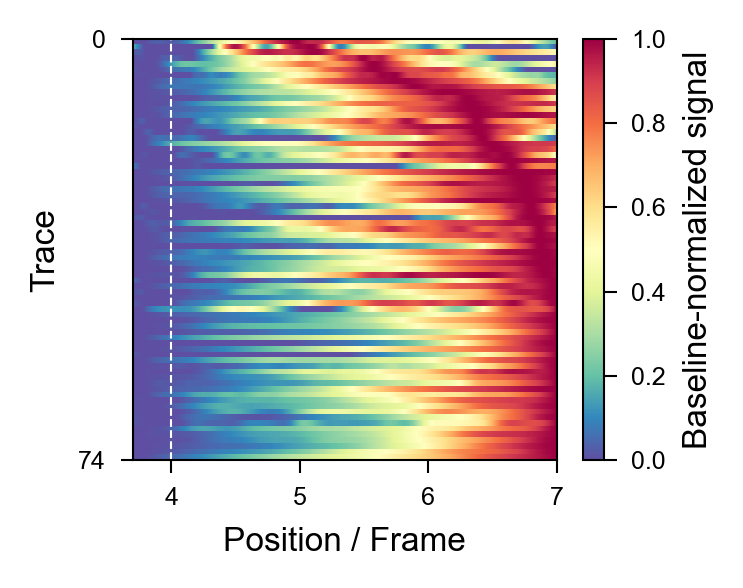

(<Figure size 750x600 with 2 Axes>,
 <Axes: xlabel='Position / Frame', ylabel='Trace'>)

In [54]:
plot_trace_heatmap(
    all_signal_sorted,
    normalize_each_row=True,
    figsize=(2.5, 2),
    xlabel="Position / Frame",
    ylabel="Trace",
    cbar_label="Signal",
    vmin=0,
    vmax=1,
    line_width = 0.5,
    first_crossing_visualize = False
)

# Figure 4E

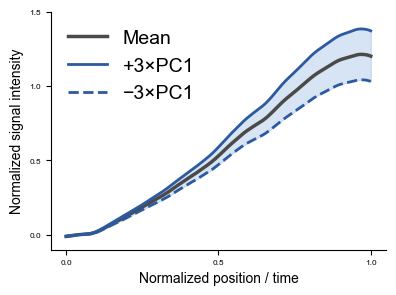

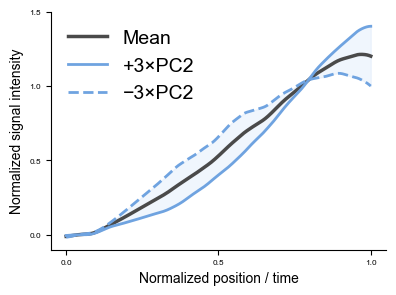

In [ ]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


pca_model = PCA(n_components = 10) 
mean_signal = pca_model.mean_
pcs = pca_model.components_

x = np.linspace(0, 1, len(mean_signal))

# ==== colors ====
dark_blue = "#2C5AA0"
light_blue = "#9BBCE3"
mean_color = "#4A4A4A"

scale = 3


# =========================
# PC1
# =========================
pc_id = 0
pc = pcs[pc_id]

plus = mean_signal + scale * pc
minus = mean_signal - scale * pc

plt.figure(figsize=(4,3))

plt.fill_between(
    x, minus, plus,
    color=light_blue,
    alpha=0.4
)

plt.plot(x, mean_signal, color=mean_color, linewidth=2.5, label="Mean")
plt.plot(x, plus, color=dark_blue, linewidth=2, label="+3×PC1")
plt.plot(x, minus, color=dark_blue, linewidth=2, linestyle="--", label="−3×PC1")

plt.xlabel("Normalized position / time", fontsize=10)
plt.ylabel("Normalized signal intensity", fontsize=10)
plt.xticks([0, 0.5, 1])
plt.yticks([0, 0.5, 1, 1.5])
plt.ylim(-0.1, 1.5)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    frameon=False,
    prop={"family": "Arial", "size": 14}  
)

plt.tight_layout()
plt.show()


# =========================
# PC2
# =========================
pc_id = 1
pc = pcs[pc_id]

plus = mean_signal + scale * pc
minus = mean_signal - scale * pc

dark_blue_pc2 = "#6FA3E0"   
light_blue_pc2 = "#D6E6FA"  

plt.figure(figsize=(4,3))

plt.fill_between(
    x, minus, plus,
    color=light_blue_pc2,
    alpha=0.35  
)

plt.plot(x, mean_signal, color=mean_color, linewidth=2.5, label="Mean")

plt.plot(
    x, plus,
    color=dark_blue_pc2,
    linewidth=2,   
    label="+3×PC2"
)

plt.plot(
    x, minus,
    color=dark_blue_pc2,
    linewidth=2,
    linestyle="--",
    label="−3×PC2"
)

plt.xlabel("Normalized position / time", fontsize=10)
plt.ylabel("Normalized signal intensity", fontsize=10)
plt.xticks([0, 0.5, 1])
plt.yticks([0, 0.5, 1, 1.5])
plt.ylim(-0.1, 1.5)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    frameon=False,
    prop={"family": "Arial", "size": 14}
)
plt.tight_layout()
plt.show()

# Figure 4F and 4G

In [ ]:
def subtrace_baseline(trace):
    trace = np.asarray(trace, dtype=float)
    return trace - np.nanmean(trace[:20])

def trace_features_with_slope_window(
    time,
    y_0,
    peak_index=None,
    slope_window=(5, 5.1)
):
    time = np.asarray(time, dtype=float)
    y = np.asarray(y_0, dtype=float)

    valid = np.isfinite(time) & np.isfinite(y)
    time = time[valid]
    y = y[valid]

    if len(y) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # =========================
    # Peak value and peak time
    # =========================
    if peak_index is None:
        peak_index = int(np.nanargmax(y))

    peak_value = y[peak_index]
    peak_time = time[peak_index]

    # =========================
    # Mean slope between 5 and 5.1
    # =========================
    dy_dt = np.gradient(y, time)

    t_start, t_end = slope_window
    slope_mask = (time >= t_start) & (time <= t_end)

    if slope_mask.sum() >= 1:
        mean_slope_window = np.nanmean(dy_dt[slope_mask])
    else:
        mean_slope_window = np.nan

    # =========================
    # Rise half-width
    # =========================
    if not np.isfinite(peak_value) or peak_value <= 0:
        return np.nan, np.nan, peak_time, peak_value, mean_slope_window

    half_value = peak_value / 2

    y_pre = y[:peak_index + 1]
    t_pre = time[:peak_index + 1]

    below = np.where(y_pre < half_value)[0]

    if len(below) == 0:
        return np.nan, np.nan, peak_time, peak_value, mean_slope_window

    i1 = below[-1]
    i2 = i1 + 1

    if i2 >= len(y_pre):
        return np.nan, np.nan, peak_time, peak_value, mean_slope_window

    t1, t2 = t_pre[i1], t_pre[i2]
    y1, y2 = y_pre[i1], y_pre[i2]

    if y2 == y1:
        left_crossing = t1
    else:
        left_crossing = t1 + (half_value - y1) * (t2 - t1) / (y2 - y1)

    rise_half_width = peak_time - left_crossing

    return rise_half_width, left_crossing, peak_time, peak_value, mean_slope_window


rise_half_widths = []
time = np.linspace(3.7, 7, 1000)
peak_values = []
peak_times = []
slopes = []
for trace in all_signal:
    # trace should be one 1D signal array
    rhw, left_crossing, peak_time, peak_value, slope_5_5p1 = trace_features_with_slope_window(
    time,
    trace,
    slope_window=(4, 4.5)
    )
    rise_half_widths.append(rhw)
    peak_values.append(peak_value)
    peak_times.append(peak_time)
    slopes.append(slope_5_5p1)

In [65]:
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

def plot_density_contour_time_axis(peak_pos, peak_val, bw):

    sns.set_theme(style="ticks")
    plt.rcParams["font.family"] = "Arial"

    peak_x = np.asarray(peak_pos, dtype=float)
    peak_val = np.asarray(peak_val, dtype=float)

    mask = (
        np.isfinite(peak_x) &
        np.isfinite(peak_val) &
        (peak_x >= 3.7) &
        (peak_x <= 7.0)
    )
    peak_x = peak_x[mask]
    peak_val = peak_val[mask]

    rho, p_value = spearmanr(peak_x, peak_val)

    blue_cmap = LinearSegmentedColormap.from_list(
        "custom_blue",
        ["#FFFFFF", "#DCEEF8", "#7FB3D5", "#2E6F95"]
    )

    plt.figure(figsize=(6, 5))

    sns.kdeplot(
        x=peak_x, y=peak_val, levels=20, fill=True,
        cmap=blue_cmap, alpha=0.35, thresh=0.05, bw_adjust=bw,
        clip=((3.7, 7.0), (None, None))
    )

    sns.kdeplot(
        x=peak_x, y=peak_val, levels=6, color="#7FB3D5",
        linewidths=1.5, fill=False, alpha=0.75, bw_adjust=bw,
        clip=((3.7, 7.0), (None, None))
    )

    plt.scatter(
        peak_x, peak_val, s=40, color="#2E6F95",
        alpha=0.9, edgecolor="white", linewidth=0.3
    )

    ax = plt.gca()

    ax.text(
    0.03, 0.97,
    rf"Spearman $\rho$ = {rho:.3f}" + "\n" + rf"$p$ = {p_value:.3g}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=22,
    fontfamily="Arial"
    )

    ax.set_xlabel("Peak position")
    ax.set_ylabel("Baseline-corrected peak height")
    ax.set_xticks([4, 5, 6, 7])
    ax.set_xlim(3.7, 7.05)

    ax.tick_params(
        axis="both", which="major",
        bottom=True, left=True,
        top=False, right=False,
        direction="out",
        length=5, width=1.2,
        labelsize=12
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)


    plt.tight_layout()
    plt.show()

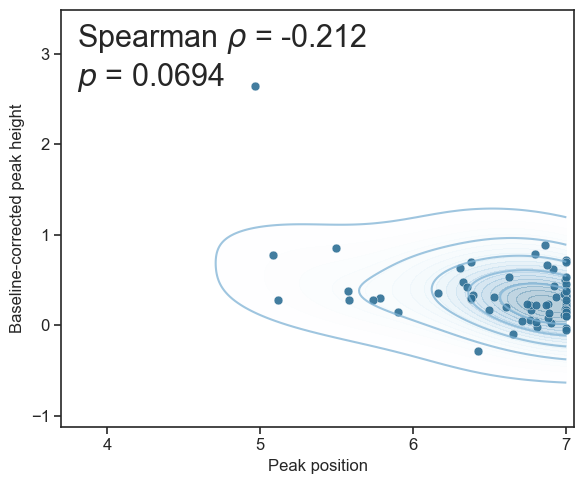

In [66]:
plot_density_contour_time_axis(peak_times, slopes, 1.6)

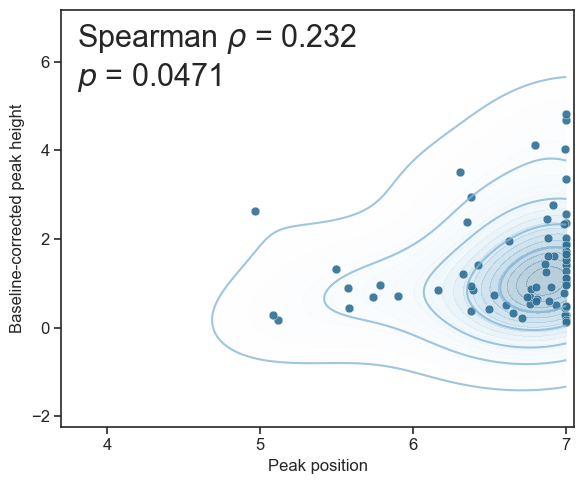

In [67]:
plot_density_contour_time_axis(peak_times, peak_values, 1.5)